In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

from transformers import DistilBertTokenizer, DistilBertModel
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast, Trainer, TrainingArguments

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics import Accuracy
from torch.utils.data import DataLoader

In [2]:
df1 = pd.read_csv("data.csv")
df1.head()

,Phrase,Intentionality
0,"I'm not entirely sure, but I think it's worth ...",Indecisive
1,"I could go either way on this, honestly.",Indecisive
2,"I’m not sure what to choose, they both seem good.",Indecisive
3,"I guess we could try it, but I’m still thinkin...",Indecisive
4,"I’m torn between the two options, I don’t know...",Indecisive


In [3]:
tint = pd.read_csv("tint.csv")
tint.head()

,tint,antonym
0,Curious,Disinterested
1,Sincere,Hypocritical
2,Responsible,Irresponsible
3,Goal-oriented,Aimless
4,Objective,Biased


In [4]:
df_train, df_test = train_test_split(df1, test_size=0.4)
df_valid, df_test = train_test_split(df_test, test_size=0.7)

df_train.head()

,Phrase,Intentionality
1107,The traditional approach always brings consist...,Traditional
3325,I’m so proud of you.,Supportive
4078,A positive outcome can result from a diplomati...,diplomatic
1021,"I’ve been thinking, and I believe this could l...",Innovative
1070,This could be the start of something truly tra...,Innovative


In [5]:
df_train.describe()

,Phrase,Intentionality
count,3229,3229
unique,3207,103
top,It doesn’t matter to me.,Confident
freq,3,63


<AxesSubplot:>

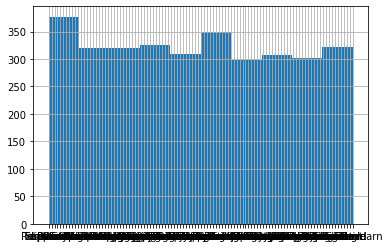

In [6]:
df_train['Intentionality'].hist()

In [7]:
def tint_coding(x, t, antonim, n, i):
    result = [0] * n

    if x == t:
        result[i] = 1
    elif x == antonim:
        result[i] = -1
    
    return result

def preprocess_data(df, tint):
    data_preprocess = []
    n = tint.shape[0]

    tint_values = tint.values
    for i in range(len(tint.values)):
        t, antonim = tint_values[i]
        cur_df = df[(df['Intentionality'] == t) | (df['Intentionality'] == antonim)]

        cur_df['Intentionality'] = cur_df['Intentionality'].apply(lambda x: tint_coding(x, t, antonim, n, i))
        data_preprocess.append(cur_df)

    result = pd.concat(data_preprocess, ignore_index=True)
    return result


In [8]:
class TorchSet(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.tokenizer = tokenizer
        self.phrase = tokenizer(df['Phrase'].tolist(), truncation=True, padding=True)
        self.tint = df['Intentionality'].values

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.phrase.items()}
        item['labels'] = torch.tensor(self.tint[idx])
        return item

    def __len__(self):
        return len(self.tint)


In [9]:
# model

In [10]:
class Classifier(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        # self.model = model
        self.tanh = nn.Tanh()
        self.layer1 = nn.Sequential(
            nn.Linear(in_features=768, out_features=768//2),
            nn.ReLU(),
            nn.Dropout(p=0.3)
        )

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=768//2, out_features=768//4),
            nn.ReLU(),
            nn.Dropout(p=0.3)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(in_features=768//4, out_features=1), 
            # nn.Tanh()
        )

        nn.init.kaiming_uniform_(self.layer1[0].weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.layer2[0].weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.layer3[0].weight)


        
    def forward(self, x, tanh=False):
        # x = model(**x)
        # print(x)
        x = F.avg_pool1d(x[0].permute(0, 2, 1), kernel_size=x[0].size(1)).squeeze(-1)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        if tanh:
            x = self.tanh(x)
        return x

In [11]:
class Tint(nn.Module):
    def __init__(self, bert, n_heads=52):
        super().__init__()

        self.n_heads = n_heads
        self.bert = bert 
        self.heads = nn.ModuleList([Classifier() for i in range(n_heads)])
        
    def forward(self, x, tanh=False):
        x = self.bert(**x)
        output = []
        for head in self.heads:
            output.append(head(x, tanh=tanh))
        x = torch.cat(output, dim=1)
        return x 

In [12]:
class TintLoss(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, y_pred, y_gt):
        loss = torch.log(torch.exp(-1 * y_pred * y_gt) + 1).mean()
        return loss 

In [13]:
l = TintLoss()
print(l(torch.Tensor([-10]), torch.Tensor([1])).item())
print(l(torch.Tensor([-10]), torch.Tensor([-1])).item())
print(l(torch.Tensor([10]), torch.Tensor([-1])).item())
print(l(torch.Tensor([10]), torch.Tensor([1])).item())

10.000045776367188
4.541770613286644e-05
10.000045776367188
4.541770613286644e-05


In [14]:
def output_process(x):
    if x < -0.3:
        return -1
    elif x > 0.3: 
        return 1
    else:
        return 0 

In [15]:
def model_train(train_loader, valid_loader, model, device=torch.device('cuda'), num_epoch=10, lr=0.01):
    train_losses = []
    valid_losses = []

    train_accuracies = []
    valid_accuracies = []

    model.to(device)

    tanh = nn.Tanh()
    accuracy = Accuracy(task='multiclass', num_classes=3)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_func = TintLoss()
    loss_func_mse = torch.nn.MSELoss()

    for epoch in tqdm(range(num_epoch)):
        model.train()
        
        batch_acc_mean = []
        total_train = 0
        total_loss = 0

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            x = {}
            x['input_ids'] = batch['input_ids']
            x['attention_mask'] = batch['attention_mask']
            
            y = batch['labels'].float()
            y_pred = model(x, tanh=False)

            # loss = loss_func(y_pred, y)
            loss = loss_func_mse(y_pred, y)
            
            # y_pred = tanh(y_pred)
            y = y.to(torch.device("cpu"))
            y_pred = y_pred.to(torch.device("cpu"))
            
            y_pred_processed = y_pred.detach().apply_(output_process)
            batch_acc = []
            for i in range(model.n_heads):
                batch_acc.append(accuracy(y_pred_processed[:, i], y[:, i]))
            
            
            batch_acc = torch.tensor(batch_acc).mean()  
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_value_(model.parameters(), 30.0)
            optimizer.step()
            
            total_loss += loss.item()
            
            batch_acc_mean.append(batch_acc)

            # _, predicted = torch.max(y_pred.data, 1)
            # _, true_value = torch.max(y.data, 1)
            # total_train += y.size(0)
            # correct_train += (predicted == true_value).sum().item()

        train_accuracy = torch.tensor(batch_acc_mean).mean() * 100
        train_accuracies.append(train_accuracy)
        train_losses.append(total_loss)

        model.eval()
        batch_acc_mean = []
        total_valid = 0
        total_loss = 0

        with torch.no_grad():
            for batch in valid_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                x = {}
                x['input_ids'] = batch['input_ids']
                x['attention_mask'] = batch['attention_mask']
                
                y = batch['labels'].float()
                y_pred = model(x, tanh=False)

                # loss = loss_func(y_pred, y)
                loss = loss_func_mse(y_pred, y)

                total_loss += loss.item()
                
                # y_pred = tanh(y_pred)
                y = y.to(torch.device("cpu"))
                y_pred = y_pred.to(torch.device("cpu"))
                
                y_pred_processed = y_pred.detach().apply_(output_process)
                batch_acc = []
                for i in range(model.n_heads):
                    batch_acc.append(accuracy(y_pred_processed[:, i], y[:, i]))
                
                
                batch_acc = torch.tensor(batch_acc).mean() 
                
                batch_acc_mean.append(batch_acc)

                # _, predicted = torch.max(y_pred.data, 1)
                # _, true_value = torch.max(y.data, 1)
                # total_valid += y.size(0)
                # correct_valid += (predicted == true_value).sum().item()

        valid_accuracy = torch.tensor(batch_acc_mean).mean() * 100
        valid_accuracies.append(valid_accuracy)
        valid_losses.append(total_loss)

        if epoch % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epoch}, Train Accuracy: {train_accuracy:.2f}%, Valid Accuracy: {valid_accuracy:.2f}%')

    return train_losses, valid_losses, train_accuracies, valid_accuracies

In [16]:
model = DistilBertModel.from_pretrained("distilbert-base-uncased")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

c:\Users\sebas\anaconda3\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [17]:
train_preprocess = preprocess_data(df_train, tint)
valid_preprocess = preprocess_data(df_valid, tint)

ds_train = TorchSet(train_preprocess, tokenizer)
ds_valid = TorchSet(valid_preprocess, tokenizer)

train_loader = DataLoader(ds_train, batch_size=50, shuffle=True)
valid_loader = DataLoader(ds_valid, batch_size=50, shuffle=True)

clf = Tint(model) 

<ipython-input-7-98c86b5b69ed>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cur_df['Intentionality'] = cur_df['Intentionality'].apply(lambda x: tint_coding(x, t, antonim, n, i))


In [18]:
param = {'train_loader': train_loader,
         'valid_loader': valid_loader,
         'model': clf,
         'num_epoch': 20,
         'lr': 0.1}

result = model_train(**param)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20, Train Accuracy: 12.22%, Valid Accuracy: 30.83%
Epoch 11/20, Train Accuracy: 94.52%, Valid Accuracy: 94.35%


In [19]:
def visualize_losses(losses, title, loc):
    
    t = np.arange(1, len(losses[0]) + 1)
    plt.figure(figsize=(12, 8))
    plt.plot(t, losses[0], label = "train")
    plt.plot(t, losses[1], label = "valid")

    plt.legend(fontsize=20, loc=loc)
    plt.xlabel("t")
    plt.ylabel("$E(t)$")
    plt.title(title)
    plt.show()

In [20]:
result[0]
result[1]

[6.104199051856995,
 2.1288771629333496,
 1.9496604204177856,
 1.5765794068574905,
 1.3246015310287476,
 1.1967029124498367,
 1.1199247613549232,
 0.8919089809060097,
 0.7752883844077587,
 0.6876327767968178,
 0.6054764874279499,
 0.5958972163498402,
 0.5335234142839909,
 0.5491478145122528,
 0.5483729168772697,
 0.5125728212296963,
 0.4999619759619236,
 0.4970656745135784,
 0.48320936411619186,
 0.4444274343550205]

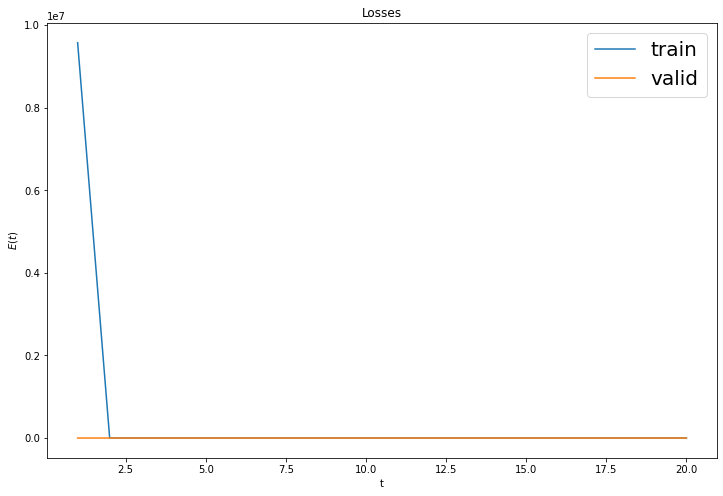

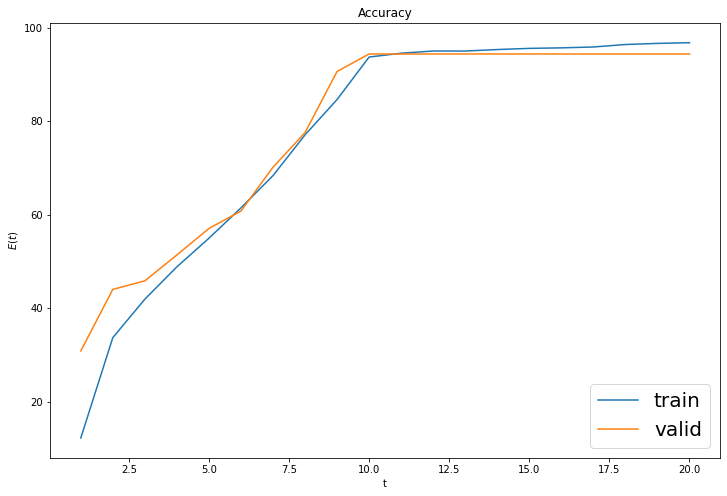

In [21]:
visualize_losses(result[:2], title='Losses', loc='upper right')
visualize_losses(result[2:], title='Accuracy', loc='lower right')

In [25]:
device = torch.device("cuda")
with torch.no_grad():
    for batch in valid_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        x = {}
        x['input_ids'] = batch['input_ids']
        x['attention_mask'] = batch['attention_mask']
        
        y_pred = clf(x, tanh=False)

        tanh = nn.Tanh()
        print(tanh(y_pred))

tensor([[ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        ...,
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123]],
       device='cuda:0')
tensor([[ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        ...,
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        [ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123]],
       device='cuda:0')
tensor([[ 0.0158,  0.0529,  0.0025,  ..., -0.0196, -0.0138,  0.1123],
        [ 0.01